In [90]:

def normalize_style(style):
    s = style
    if s in ["Even 8th's", "Even 8's"]:
        return 'Even 8ths'
    if 'Swing' in s or 'Fusion' in s or 'Jazz' in s:
        return 'Jazz'
    if 'Blues' in s:
        return 'Blues'
    if 'Folk' in s:
        return 'Folk'
    if 'Bossa' in s:
        return 'Bossa'
    if 'Reggae' in s:
        return 'Reggae'
    if 'Samba' in s:
        return 'Samba'
    if 'Funk' in s:
        return 'Funk'
    if 'Pop' in s:
        return 'Pop'
    if 'Son' in s:
        return 'Son'
    if 'Rock' in s or s == 'Beatles':
        return 'Rock'
    if 'Soul' in s:
        return 'Soul'
    if 'Balad' in s:
        return 'Balad'
    if s == "R'n'B":
        return "RnB"
    if s == 'Afoxe':
        return 'Afoxé'
    if s in ['Worship', 'Traditional Gospel']:
        return 'Gospel'
    if s == 'Even 8ths':
        return 'Pop'
    return s

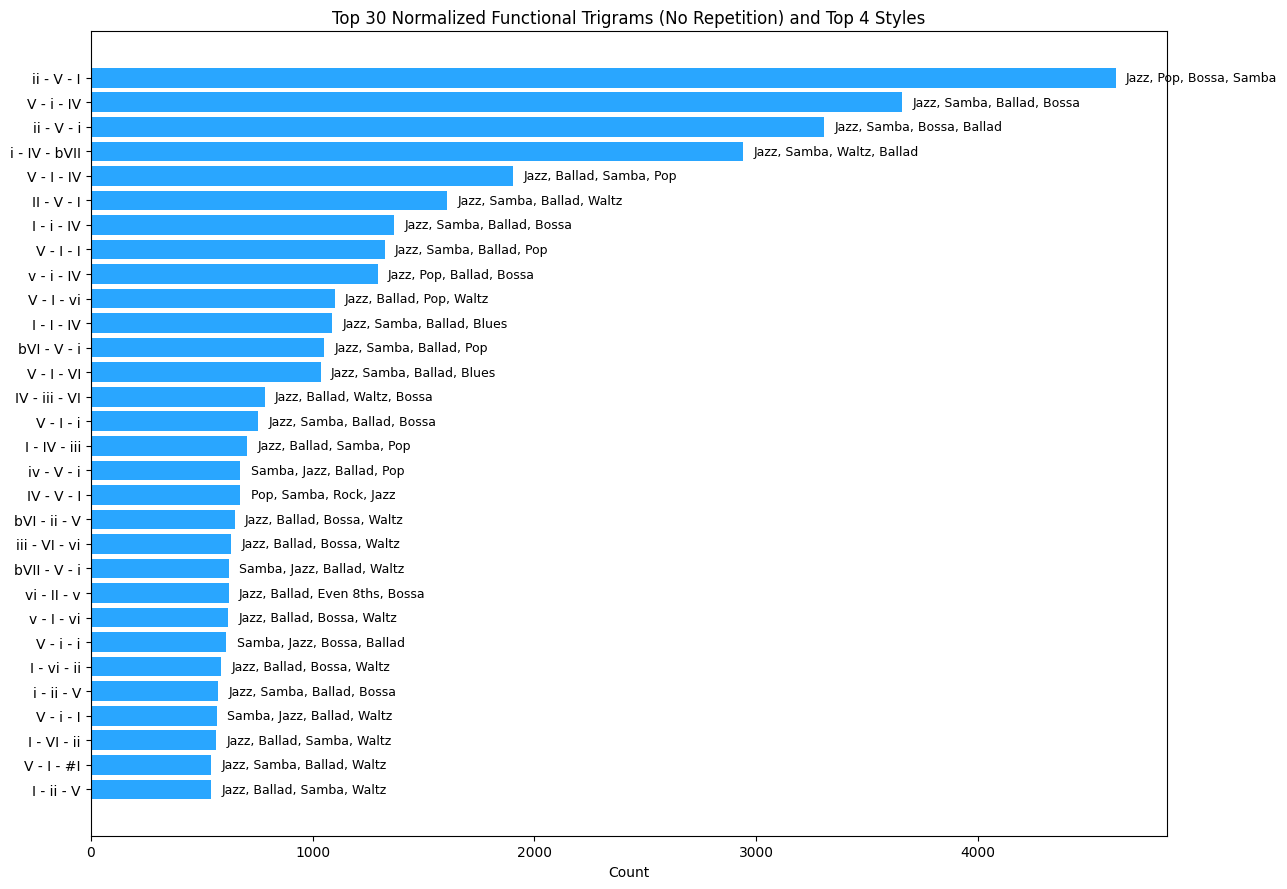

In [91]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

def normalize_function_label(label):
    # Remove accidentals, extensions, and alterations: keep only Roman numerals and accidentals at start
    match = re.match(r"([b#♭♯]*[IViv]+)", label)
    return match.group(1) if match else label

def normalize_trigram(function_trigram):
    # Return canonicalized tuple of roman numerals
    return tuple(normalize_function_label(x) for x in function_trigram)

# Load data
with open('/workspace/dataset/trigrams/trigram_dataset.json', 'r') as f:
    data = json.load(f)

# Aggregate: trigram -> count, style counter
trigram_count = Counter()
trigram_styles = defaultdict(Counter)

for entry in data:
    func_trigram = normalize_trigram(entry['function'])
    if len(set(func_trigram)) == 1:
        continue
    count = entry['count']
    for style in entry['styles']:
        norm_style = normalize_style(style)
        trigram_styles[func_trigram][norm_style] += count
    trigram_count[func_trigram] += count

# Select top 
selected = 30
top_trigrams = trigram_count.most_common(selected)

# Prepare for plotting
plot_labels = []
plot_counts = []
plot_topstyles = []

num_styles = 4
for trigram, count in top_trigrams:
    roman_label = ' - '.join(trigram)
    styles_counter = trigram_styles[trigram]
    top_n_styles = [s for s, _ in styles_counter.most_common(num_styles)]
    plot_labels.append(roman_label)
    plot_counts.append(count)
    plot_topstyles.append(', '.join(top_n_styles))

# Reverse for horizontal plot (most common at top)
plot_labels = plot_labels[::-1]
plot_counts = plot_counts[::-1]
plot_topstyles = plot_topstyles[::-1]

# Plot
fig, ax = plt.subplots(figsize=(13, 9))
bars = ax.barh(plot_labels, plot_counts, color="#29a6ff")

for i, (c, styles) in enumerate(zip(plot_counts, plot_topstyles)):
    ax.text(c + max(plot_counts) * 0.01, i, styles, va='center', fontsize=9, color="#000000")

ax.set_xlabel('Count')
ax.set_title(f'Top {selected} Normalized Functional Trigrams (No Repetition) and Top {num_styles} Styles')
plt.tight_layout()
plt.show()


/tmp/ipykernel_130099/2037479474.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=text_size)
/tmp/ipykernel_130099/2037479474.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)


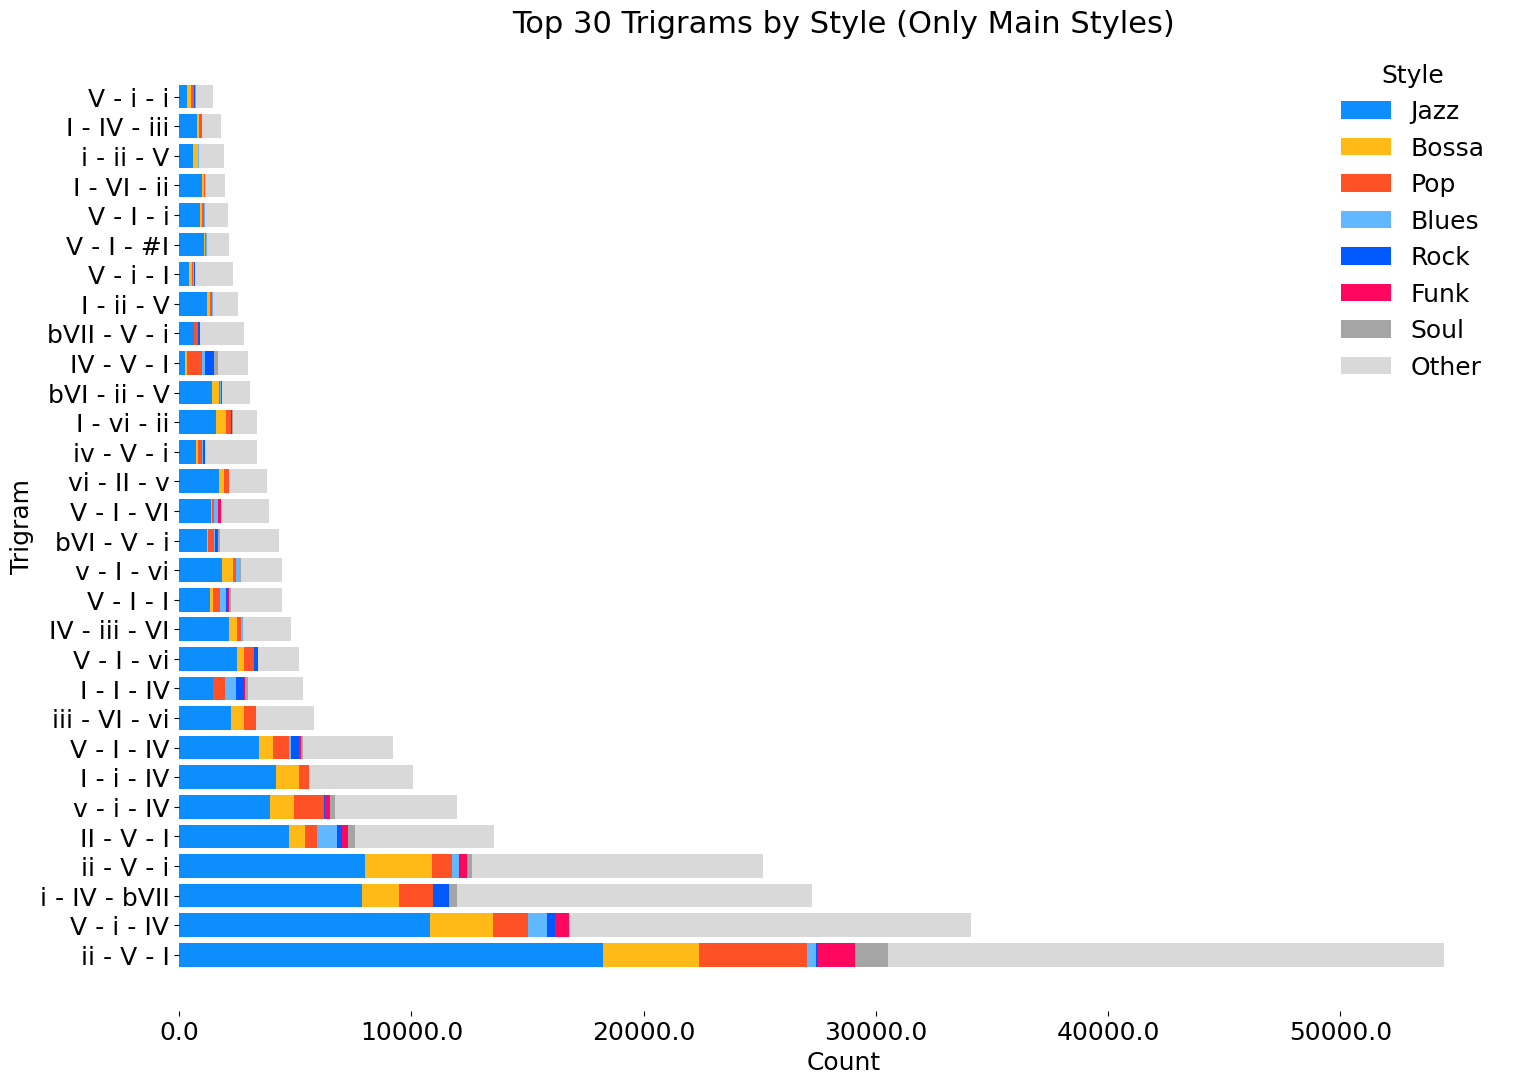

In [92]:
import numpy as np
import matplotlib.pyplot as plt

N = 30
chosen_styles = ['Jazz', 'Bossa', 'Pop', 'Blues', 'Rock', 'Funk', 'Soul']

# Get top N trigrams
top_trigrams = sorted(trigram_count.items(), key=lambda x: x[1], reverse=True)[:N]
labels = [' - '.join(trigram) for trigram, _ in top_trigrams]

# Build the data matrix and compute total counts for sorting
data = []
totals = []
for trigram, _ in top_trigrams:
    style_counts = trigram_styles[trigram]
    row = [style_counts.get(style, 0) for style in chosen_styles]
    other_count = sum(v for k, v in style_counts.items() if k not in chosen_styles)
    row.append(other_count)
    data.append(row)
    totals.append(sum(row))
data = np.array(data)

# Sort by total count (descending)
sorted_idx = np.argsort(totals)[::-1]
data = data[sorted_idx]
labels = [labels[i] for i in sorted_idx]

# Custom colors for these genres
custom_palette = {
    'Jazz': "#0c8eff",
    'Bossa': "#ffba18",
    'Pop': "#ff5125",
    'Blues': "#61b8ff",
    'Rock': "#0059ff",
    'Funk': "#ff075e",
    'Soul': "#a5a5a5",
    'Other': "#d9d9d9",
}
bar_colors = [custom_palette.get(style, '#636e72') for style in chosen_styles + ['Other']]

# Plot
fig, ax = plt.subplots(figsize=(15, 10))
left = np.zeros(len(labels))
for i, (style, color) in enumerate(zip(chosen_styles + ['Other'], bar_colors)):
    ax.barh(labels, data[:, i], left=left, label=style, color=color)
    left += data[:, i]

# Remove frame
for spine in ax.spines.values():
    spine.set_visible(False)
text_size = 18
# Set bigger font sizes
ax.set_xlabel('Count', fontsize=text_size)
ax.set_ylabel('Trigram', fontsize=text_size)
ax.set_title(f'Top {N} Trigrams by Style (Only Main Styles)', fontsize=22)
ax.set_yticklabels(labels, fontsize=text_size)
ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)

# Legend with bigger font
ax.legend(title='Style', fontsize=text_size, title_fontsize=text_size, loc='upper right', frameon=False)

plt.tight_layout(pad=0.1)
plt.subplots_adjust(bottom=0.01, top=0.98)
plt.show()



In [93]:
import re

def split_function_label(label):
    match = re.match(r"^([b#♭♯]*[IViv]+)(.*)$", label)
    if match:
        degree = match.group(1)
        extension = match.group(2)
        return degree, extension
    else:
        return label, ""

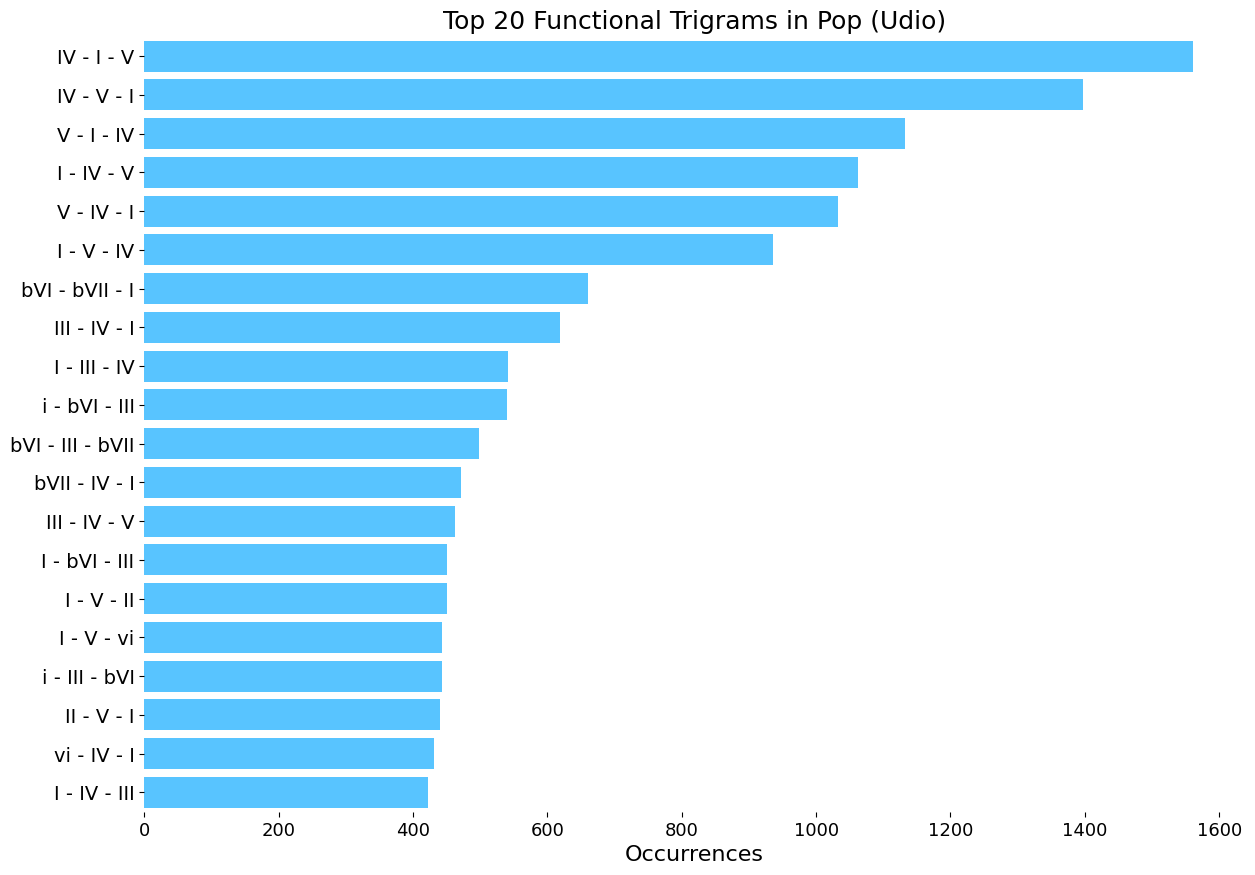

In [94]:
import json
import matplotlib.pyplot as plt

collection = 'udio'
path = f'/workspace/ngram_datasets/trigrams/3gram_dataset_{collection}.json'
# Load the data
with open(path, 'r') as f:
    data = json.load(f)

# Extract trigrams with Pop in styles, and get their Pop count
pop_trigrams = []
style = 'pop'
for entry in data:
    for s, count in entry['dortmund_genres']:
        if s == style:
            pop_trigrams.append({
                "function": entry['ngram'],
                "pop_count": count
            })
            break

N = 20
# Sort by Pop count, descending
pop_trigrams = sorted(pop_trigrams, key=lambda x: x['pop_count'], reverse=True)[:N]

# Prepare data for plotting
labels = [' - '.join(tri['function']) for tri in pop_trigrams]
counts = [tri['pop_count'] for tri in pop_trigrams]

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(labels[::-1], counts[::-1], color="#58c4ff")

# Remove all spines (the box/frame)
for spine in ax.spines.values():
    spine.set_visible(False)

# Tighten layout
plt.tight_layout(pad=0.05)

# Set y-limits to crop empty space
ax.set_ylim(-0.5, len(labels) - 0.5)  # Half-bar padding

ax.set_xlabel('Occurrences', fontsize=16)
ax.set_title('Top 20 Functional Trigrams in {} ({})'.format(style.capitalize(), collection.capitalize()), fontsize=18)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=13)

plt.show()

In [95]:
from trigram_search import query_trigram_usage

result = query_trigram_usage(["ii", "V", "I"])
print(result)


{'functional_trigrams': {'count': 4620, 'styles': [['Jazz', 18241], ['Pop', 4641], ['Bossa', 4151], ['Samba', 4031], ['Ballad', 4030], ['Latin', 3201], ['Waltz', 3197], ['Bolero', 1814], ['Gospel', 1619], ['Funk', 1597]], 'matched': 'exact', 'function': ['ii', 'V', 'I']}, 'trigram_dataset': {'total_count': 10298, 'styles': [('Medium Swing', 8565), ('Ballad', 8160), ('Samba', 6991), ('Medium Up Swing', 6639), ('Up Tempo Swing', 6534), ('Waltz', 6392), ('Bossa Nova', 6231), ('Slow Swing', 5713), ('Latin', 5194), ('Even 8ths', 2645)], 'composers': [('Richard Rodgers', 5151), ('Harold Arlen', 5005), ('Cole Porter', 4630), ('George Gershwin', 4550), ('Duke Ellington', 4444), ('Exercise', 4430), ('Antonio-Carlos Jobim', 4319), ('Jimmy Van-Heusen', 4199), ('Hoagy Carmichael', 3941), ('Frank Loesser', 3886)]}}


{'functional_trigrams': {'count': 674, 'styles': [['Pop', 680], ['Samba', 441], ['Rock', 403], ['Jazz', 270], ['Soul', 150], ['Gospel', 137], ['Folk', 123], ['Ballad', 103], ['Blues', 102], ['Latin', 82]], 'matched': 'exact', 'function': ['IV', 'V', 'I']}, 'trigram_dataset': {'total_count': 1817, 'styles': [('Samba', 924), ('Medium Swing', 642), ('Ballad', 462), ('Samba Enredo', 407), ('Rock Pop', 395), ('Rock', 357), ('Pop', 308), ('Up Tempo Swing', 226), ('Latin', 209), ('Waltz', 203)], 'composers': [('The Beatles (Lennon, McCartney)', 295), ('Nelson Cavaquinho', 276), ('Zeca Pagodinho', 235), ('Fundo de Quintal', 218), ('Roberto Ribeiro', 184), ('Gonzaguinha', 173), ('João Nogueira', 171), ('Martinho da Vila', 160), ('Chico Buarque', 149), ('GRES Salgueiro 2010', 146)]}}


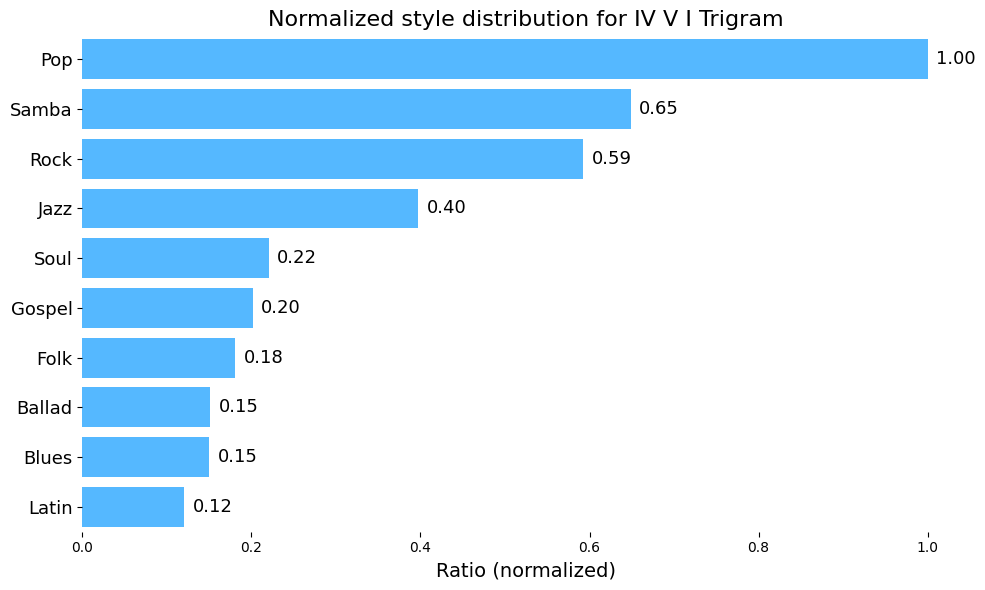

In [96]:
import matplotlib.pyplot as plt

find = ["IV", "V", "I"]

result = query_trigram_usage(find)

print(result)

styles_counts = result["functional_trigrams"]["styles"]
if not styles_counts:
    print("No styles to plot.")
else:
    labels, counts = zip(*styles_counts)
    counts = list(counts)
    max_count = max(counts)
    norm_counts = [c / max_count for c in counts]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(labels[::-1], norm_counts[::-1], color="#55b8ff", edgecolor="none")

    # Remove frame
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_ylim(-0.5, len(labels) - 0.5)

    # Add ratio labels
    for bar in bars:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.2f}", va='center', fontsize=13)

    ax.set_xlabel("Ratio (normalized)", fontsize=14)
    ax.set_title('Normalized style distribution for ' + ' '.join(find) + ' Trigram', fontsize=16)
    ax.tick_params(axis='y', labelsize=13)
    plt.tight_layout()
    plt.show()


In [97]:
import json
from collections import Counter

type = "suno"
path = f"/workspace/ngram_datasets/trigrams/3gram_dataset_{type}.json"

with open(path) as f:
    trigram_data = json.load(f)

genre_counter = Counter()

for entry in trigram_data:
    # entry['genres'] is a list of [genre, weight]
    for genre, weight in entry.get('genres', []):
        genre_counter[genre] += weight

# Print top N genres
N = 30
print("Most common Dortmund genres in", type, "trigrams:")
for genre, weight in genre_counter.most_common(N):
    print(f"{genre:15} {weight:.2f}")


Most common Dortmund genres in suno trigrams:


In [98]:
from collections import defaultdict
import numpy as np

N = 30
# Include 'pop' and any other Dortmund genres you care about
chosen_styles = ['rock', 'electronic', 'jazz', 'pop', 'alternative', 'raphiphop', 'folkcountry', 'funksoulrnb', 'blues']

trigram_count = {}
trigram_genres = defaultdict(dict)

for entry in trigram_data:
    trigram = tuple(entry['ngram'])
    count = entry['count']
    trigram_count[trigram] = count
    # genres is a list of [genre, float sum]
    genre_counts = {k.lower(): v for k, v in entry['dortmund_genres']}  # always lowercase for safety
    trigram_genres[trigram] = genre_counts

# Get top N trigrams by total count
top_trigrams = sorted(trigram_count.items(), key=lambda x: x[1], reverse=True)[:N]
labels = [' - '.join(trigram) for trigram, _ in top_trigrams]

# Build data matrix (main genres + 'other')
data = []
totals = []
for trigram, _ in top_trigrams:
    genre_counts = trigram_genres[trigram]
    row = [genre_counts.get(style, 0) for style in chosen_styles]
    # "other" is sum of all dormund genres not in chosen_styles
    other_count = sum(v for k, v in genre_counts.items() if k not in chosen_styles)
    row.append(other_count)
    data.append(row)
    totals.append(sum(row))
data = np.array(data)

# Sort by total count (descending) (this actually does nothing since already sorted)
sorted_idx = np.argsort(totals)[::-1]
data = data[sorted_idx]
labels = [labels[i] for i in sorted_idx]


/tmp/ipykernel_130099/1333933885.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=text_size)
/tmp/ipykernel_130099/1333933885.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)


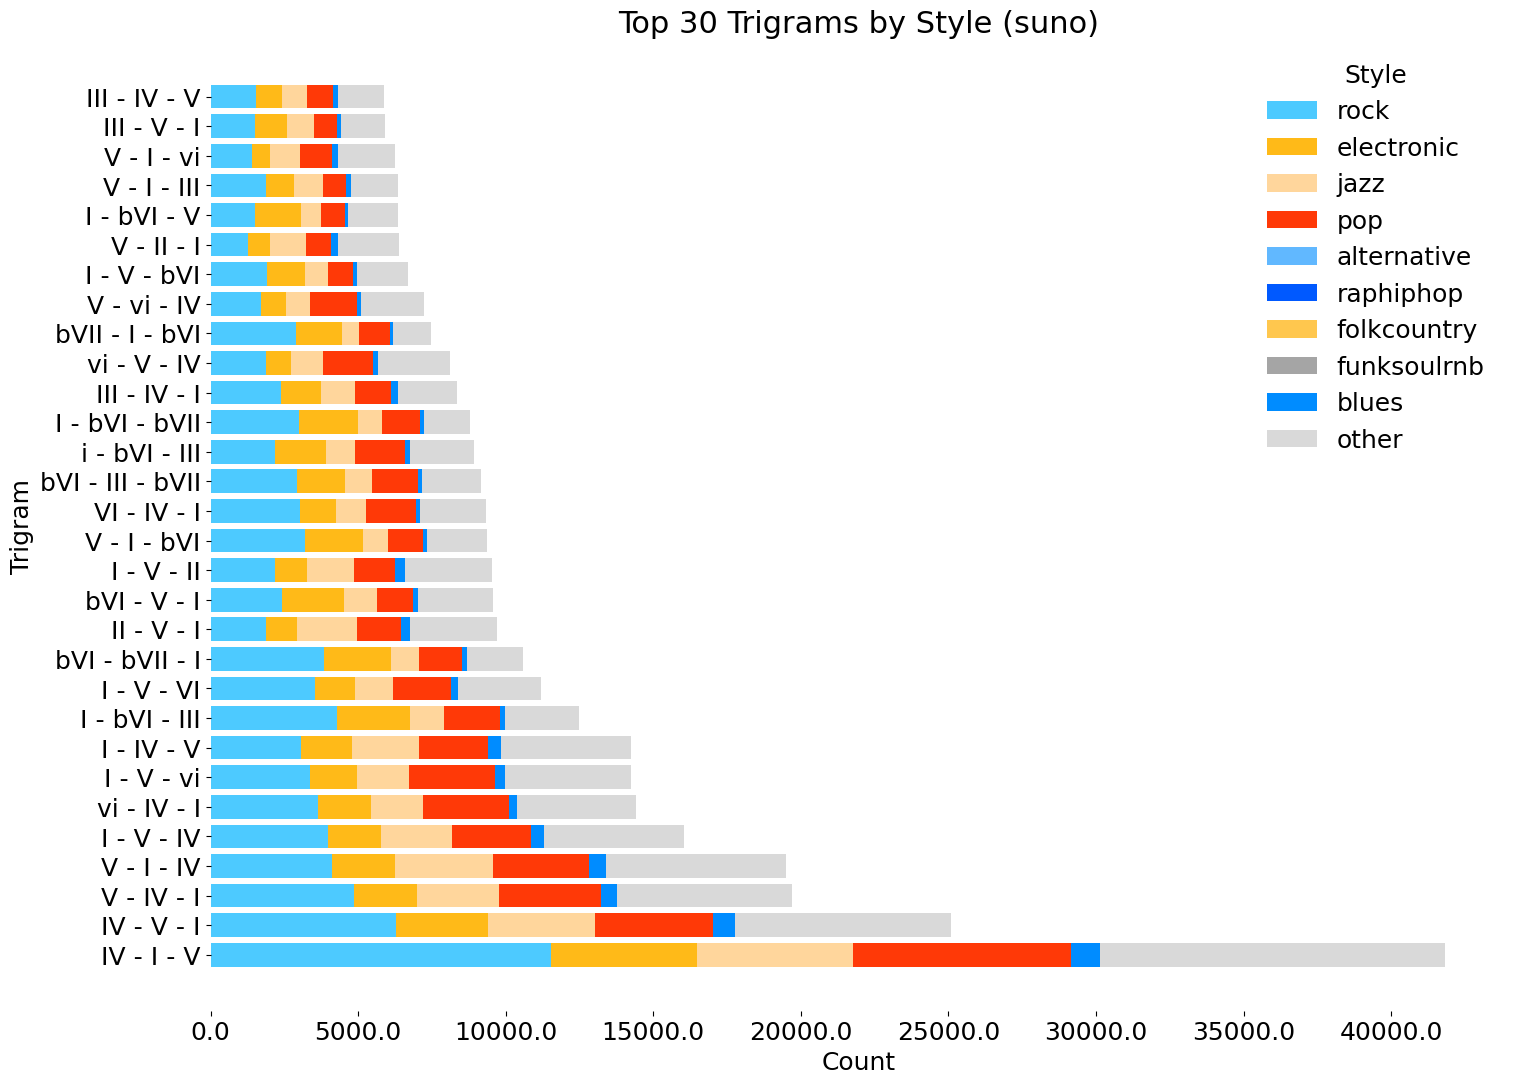

In [99]:
import matplotlib.pyplot as plt


custom_palette = {
    'rock': "#4dcaff",
    'electronic': "#ffba18",
    'jazz': "#ffd69c",
    'pop': "#ff3907",
    'alternative': "#61b8ff",
    'raphiphop': "#0059ff",
    'folkcountry': "#ffc74e",
    'funksoulrnb': "#a5a5a5",
    'blues': "#008cff",
    'other': "#d9d9d9",
}
bar_colors = [custom_palette.get(style, '#636e72') for style in chosen_styles + ['other']]

fig, ax = plt.subplots(figsize=(15, 10))
left = np.zeros(len(labels))
for i, (style, color) in enumerate(zip(chosen_styles + ['other'], bar_colors)):
    ax.barh(labels, data[:, i], left=left, label=style, color=color)
    left += data[:, i]

for spine in ax.spines.values():
    spine.set_visible(False)
text_size = 18
ax.set_xlabel('Count', fontsize=text_size)
ax.set_ylabel('Trigram', fontsize=text_size)
ax.set_title(f'Top {N} Trigrams by Style ({type})', fontsize=22)
ax.set_yticklabels(labels, fontsize=text_size)
ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)
ax.legend(title='Style', fontsize=text_size, title_fontsize=text_size, loc='upper right', frameon=False)

plt.tight_layout(pad=0.1)
plt.subplots_adjust(bottom=0.01, top=0.98)
plt.show()


/tmp/ipykernel_130099/135382535.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{t/total_overall:.0%}' for t in ticks], fontsize=text_size)


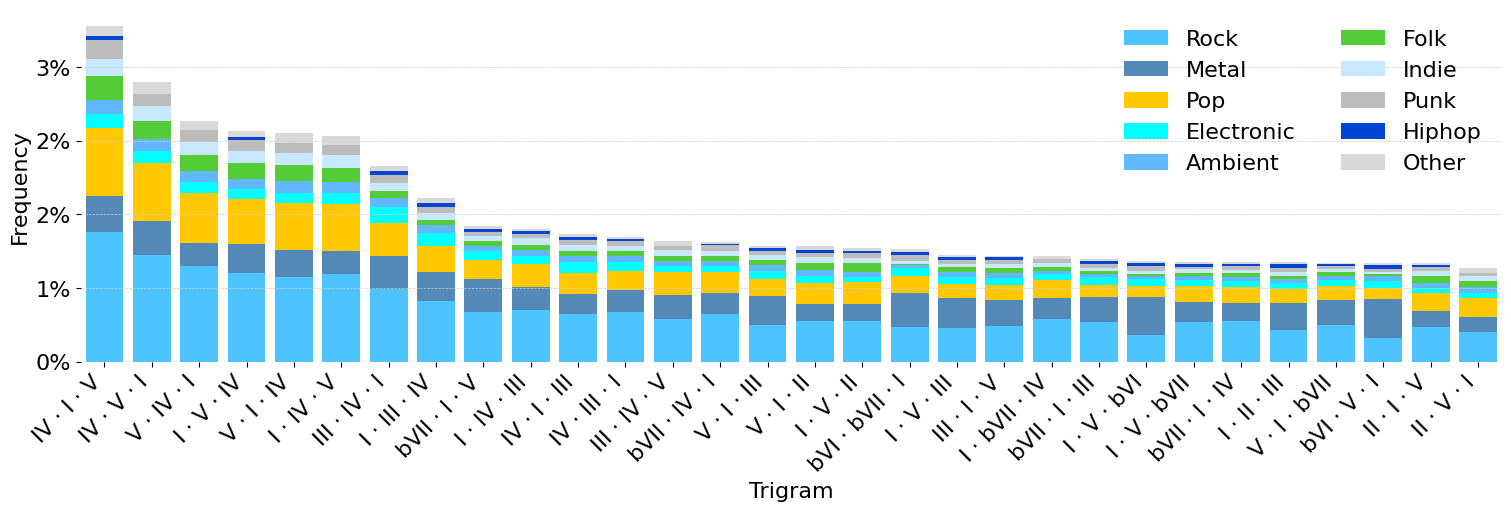

saved ../Figures/01_lastfm_top_30.png


/tmp/ipykernel_130099/135382535.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{t/total_overall:.0%}' for t in ticks], fontsize=text_size)


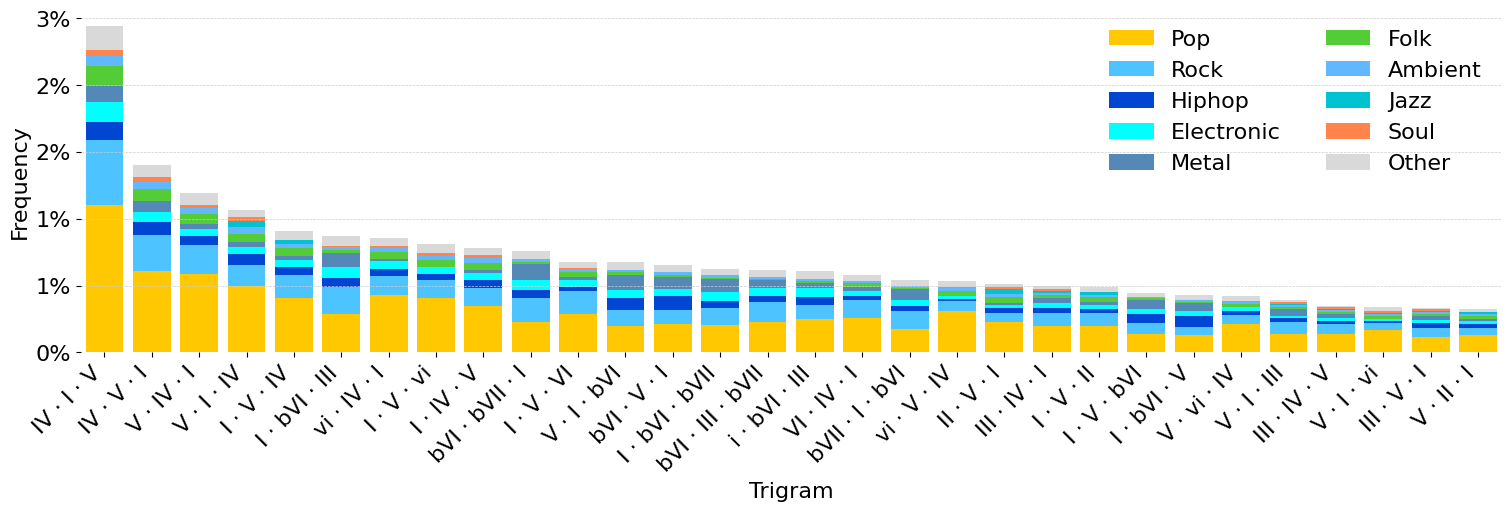

saved ../Figures/02_suno_top_30.png


/tmp/ipykernel_130099/135382535.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{t/total_overall:.0%}' for t in ticks], fontsize=text_size)


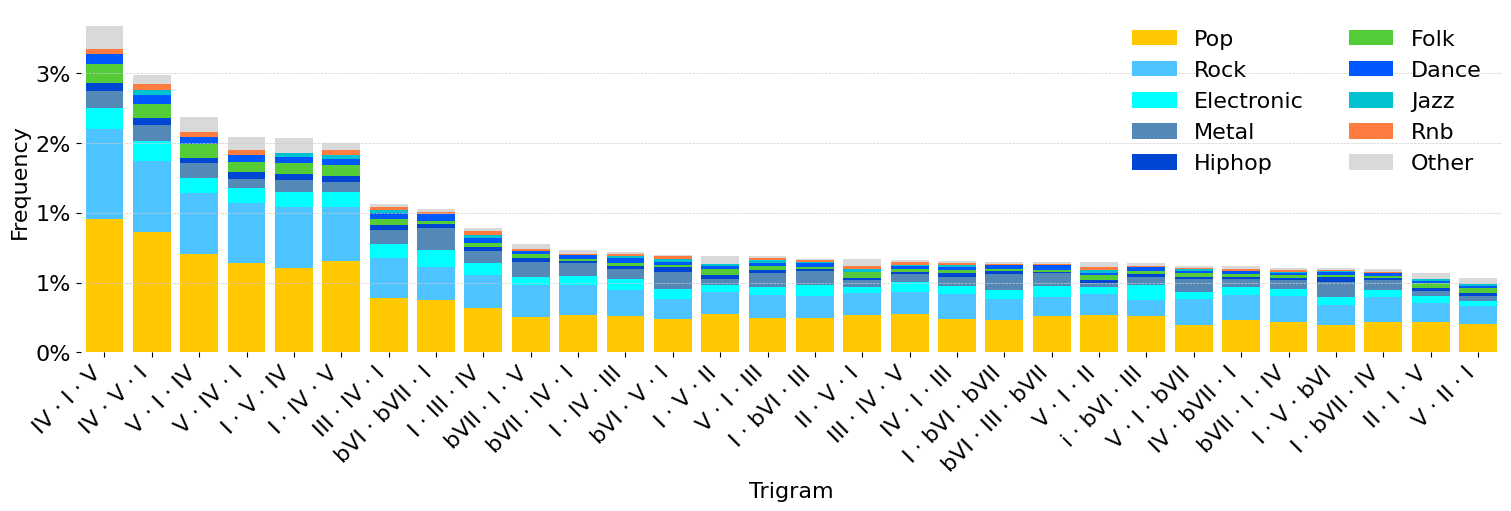

saved ../Figures/03_udio_top_30.png


In [100]:
import json
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import json

collection = ["lastfm", "suno", "udio"]
id = 1
for type in collection:
    path = f"/workspace/ngram_datasets/trigrams/3gram_dataset_{type}.json"

    with open(path) as f:
        trigram_data = json.load(f)

    # Build all_styles
    all_styles = Counter()
    for entry in trigram_data:
        for style, count in entry.get('human_styles', []):
            all_styles[style.lower()] += count

    N_styles = 9  # top N
    chosen_styles = [s for s, _ in all_styles.most_common(N_styles)]

    custom_palette = {
        'pop':      "#FFC800",
        'rock':     "#4DC3FF",
        'electronic': "#00FFFF",
        'hiphop':   "#0046D2",
        'country':  "#FB9530",
        'ambient':  "#61B8FF",
        'metal':    "#5488B6",
        'punk':     "#BCBCBC",
        'soul':     "#FF844B",
        'dance':    "#0059FF",
        'folk':     "#53CC38",
        'funk':     "#ACDEFF",
        'blues':    "#69E1FF",
        'jazz':     "#00C2D1",
        'rnb':      "#FF7C40",
        'indie' :   "#C8E8FF",
        'other':    "#d9d9d9",
    }

    all_plot_styles = chosen_styles + ['other']
    bar_colors = [custom_palette.get(style, "#dddddd") for style in all_plot_styles]

    # (Rest of your matrix-building and plotting code—unchanged)
    trigram_count = {}
    trigram_styles = defaultdict(dict)

    for entry in trigram_data:
        trigram = tuple(entry['ngram'])
        count = entry['count']
        trigram_count[trigram] = count
        style_counts = {k.lower(): v for k, v in entry['human_styles']}
        trigram_styles[trigram] = style_counts

    N = 30
    top_trigrams = sorted(trigram_count.items(), key=lambda x: x[1], reverse=True)[:N]
    labels = [' · '.join(trigram) for trigram, _ in top_trigrams]

    data = []
    totals = []
    for trigram, _ in top_trigrams:
        style_counts = trigram_styles[trigram]
        row = [style_counts.get(style, 0) for style in chosen_styles]
        other_count = sum(v for k, v in style_counts.items() if k not in chosen_styles)
        row.append(other_count)
        data.append(row)
        totals.append(sum(row))
    data = np.array(data)
    sorted_idx = np.argsort(totals)[::-1]
    data = data[sorted_idx]
    labels = [labels[i] for i in sorted_idx]

    fig, ax = plt.subplots(figsize=(15, 5))     # wider than tall

    bottom = np.zeros(len(labels))              # where each stacked segment starts
    for style, color, column in zip(all_plot_styles, bar_colors, data.T):
        ax.bar(labels, column, bottom=bottom,    # <-- vertical stacked bars
            label=style.capitalize(), color=color)
        bottom += column

    total_overall = sum(trigram_count.values()) 
    ticks = ax.get_yticks()
    text_size = 16
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    ax.grid(axis='y',                      # only horizontal lines
        linestyle='--',                # dashed
        linewidth=0.5,
        color="#cdcdcd",
        alpha=1.0) 

    ax.set_xlabel('Trigram', fontsize=text_size)
    ax.set_ylabel('Frequency',   fontsize=text_size)
    # ax.set_title(f'Top {N} Trigrams by Style ({type.capitalize()})', fontsize=text_size, pad=10)
    
    ax.set_xlim(-0.5, len(labels) - 0.5)
    # rotate long trigram labels so they fit
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=text_size)

    # show counts in thousands on y-axis, if you like
    ax.set_yticklabels([f'{t/total_overall:.0%}' for t in ticks], fontsize=text_size)
    ax.margins(x=0) 
    
    ax.legend(fontsize=text_size, frameon=False, ncol=len(all_plot_styles)//4)
    plt.tight_layout(pad=0.3)
    plt.show()
    out_name = f"{id:02d}_{type}_top_30.png"   # 01_lastfm_top_30.png, …
    path = f"../Figures/{out_name}"
    fig.savefig(path, dpi=300, bbox_inches='tight')  # high-res, trimmed
    print(f"saved {path}")
    id += 1


In [101]:
trigram_targets = [
    ('I', 'V', 'VI'),
    ('IV', 'V', 'vi'),
    ('I', 'V', 'vi'),
    ('vi', 'IV', 'V'),
    ('vi', 'IV', 'I'),
    ('VI', 'IV', 'I'),
    ('V', 'vi', 'IV'),
    ('V', 'I', 'bVI'),
    ('IV', 'I', 'V'),
    ('IV', 'V', 'I'),
    ('V', 'I', 'IV'),
    ('VI', 'IV', 'V'),
    ('I', 'V', 'IV'),
    ('V', 'vi', 'I')
]
# If you want all rotations for each, also do:
all_target_trigrams = set()
for tri in trigram_targets:
    for i in range(3):
        all_target_trigrams.add(tuple(list(tri[i:]) + list(tri[:i])))


In [102]:
from collections import defaultdict, Counter
import json

collections = ['lastfm', 'suno', 'udio']
style_collection_trigram_counts = defaultdict(lambda: defaultdict(Counter))
total_style_collection_counts = defaultdict(lambda: defaultdict(int))

# Count for each collection
for collection in collections:
    with open(f"../ngram_datasets/trigrams/3gram_dataset_{collection}.json") as f:
        trigram_data = json.load(f)
    for entry in trigram_data:
        trigram = tuple(entry['ngram'])
        style_counts = entry.get('human_styles', [])
        if trigram in all_target_trigrams:
            for style, count in style_counts:
                style_collection_trigram_counts[trigram][collection][style] += count
        for style, count in style_counts:
            total_style_collection_counts[collection][style] += count

# (rest of your code: enrichment, Fisher's test, results, DataFrame as before)


In [103]:
enrichment = {}
for trigram in all_target_trigrams:
    enrichment[trigram] = {}
    for collection in style_collection_trigram_counts[trigram]:
        enrichment[trigram][collection] = {}
        for style, count in style_collection_trigram_counts[trigram][collection].items():
            total = total_style_collection_counts[collection][style]
            proneness = count / total if total else 0
            enrichment[trigram][collection][style] = proneness


In [104]:
from scipy.stats import fisher_exact
results = []

for trigram in all_target_trigrams:
    for collection in style_collection_trigram_counts[trigram]:
        for style in style_collection_trigram_counts[trigram][collection]:
            a = style_collection_trigram_counts[trigram][collection][style]
            b = total_style_collection_counts[collection][style] - a
            c = sum(style_collection_trigram_counts[trigram][collection][s] for s in total_style_collection_counts[collection] if s != style)
            d = sum(total_style_collection_counts[collection][s] for s in total_style_collection_counts[collection] if s != style) - c

            # Patch for valid Fisher's input
            if all(x >= 0 for x in [a, b, c, d]) and (a + b + c + d) > 0:
                oddsratio, pvalue = fisher_exact([[a, b], [c, d]])
            else:
                oddsratio, pvalue = float('nan'), float('nan')

            # Also calculate proneness as defined before
            total = total_style_collection_counts[collection][style]
            proneness = a / total if total else 0

            results.append({
                "Trigram": "-".join(trigram),
                "Collection": collection,
                "Style": style,
                "Proneness": proneness,
                "OddsRatio": oddsratio,
                "P-value": pvalue,
                "Count_in_style": a,
                "Total_in_style": total,
            })


In [105]:
import pandas as pd

df_results = pd.DataFrame(results)
# Sort for most significant
df_results = df_results.sort_values(["Trigram", "Collection", "P-value"])

# Only show "significant" results (optional)
sig = df_results[df_results["P-value"] < 0.05]

# print all the list
print("All results:")
# print(df_results.to_string(index=False))


All results:


In [106]:
print(df_results.shape)
print(df_results.head(10))


(810, 8)
    Trigram Collection       Style  Proneness  OddsRatio        P-value  \
270  I-IV-V     lastfm        rock   0.006162   1.401727   0.000000e+00   
272  I-IV-V     lastfm       metal   0.002210   0.380913   0.000000e+00   
278  I-IV-V     lastfm     country   0.020004   4.181126   0.000000e+00   
271  I-IV-V     lastfm         pop   0.006434   1.378725  1.386644e-211   
273  I-IV-V     lastfm        folk   0.008232   1.711801  1.999504e-194   
274  I-IV-V     lastfm       indie   0.007688   1.589841  2.066855e-135   
276  I-IV-V     lastfm  electronic   0.003846   0.763849   8.060140e-51   
277  I-IV-V     lastfm        punk   0.006595   1.348714   2.735623e-47   
279  I-IV-V     lastfm        jazz   0.003780   0.758724   5.219414e-17   
275  I-IV-V     lastfm     ambient   0.005524   1.121974   1.104611e-09   

     Count_in_style  Total_in_style  
270           23829         3866981  
272            6334         2866123  
278            1558           77886  
271          

In [107]:
from statsmodels.stats.proportion import proportions_ztest

collections = ['lastfm', 'suno', 'udio']
target_trigrams = all_target_trigrams  # as previously defined

# Step 1: Count canonical trigrams and total trigrams per collection
canonical_counts = {}
total_counts = {}
for collection in collections:
    with open(f"../ngram_datasets/trigrams/3gram_dataset_{collection}.json") as f:
        trigram_data = json.load(f)
    canonical = 0
    total = 0
    for entry in trigram_data:
        trigram = tuple(entry['ngram'])
        count = entry['count'] if 'count' in entry else 1
        total += count
        if trigram in target_trigrams:
            canonical += count
    canonical_counts[collection] = canonical
    total_counts[collection] = total

print("Canonical trigram counts:", canonical_counts)
print("Total trigram counts:", total_counts)

# Step 2: Calculate and print proportions
for collection in collections:
    frac = canonical_counts[collection] / total_counts[collection] if total_counts[collection] > 0 else 0
    print(f"{collection}: {canonical_counts[collection]} / {total_counts[collection]} = {frac:.6f}")

# Step 3: Statistical test - SUNO vs LASTFM, SUNO vs UDIO
for other in ['lastfm', 'udio']:
    count = [canonical_counts['suno'], canonical_counts[other]]
    nobs = [total_counts['suno'], total_counts[other]]
    stat, pval = proportions_ztest(count, nobs)
    print(f"\nSuno vs {other}:")
    print(f"  SUNO: {count[0]}/{nobs[0]} ({count[0]/nobs[0]:.6f})")
    print(f"  {other.upper()}: {count[1]}/{nobs[1]} ({count[1]/nobs[1]:.6f})")
    print(f"  z={stat:.2f}, p-value={pval:.5g}")
    if pval < 0.05:
        print("  --> Difference is SIGNIFICANT.")
    else:
        print("  --> Difference is NOT significant.")


Canonical trigram counts: {'lastfm': 135121, 'suno': 262111, 'udio': 90473}
Total trigram counts: {'lastfm': 2480124, 'suno': 1616453, 'udio': 1366490}
lastfm: 135121 / 2480124 = 0.054482
suno: 262111 / 1616453 = 0.162152
udio: 90473 / 1366490 = 0.066208

Suno vs lastfm:
  SUNO: 262111/1616453 (0.162152)
  LASTFM: 135121/2480124 (0.054482)
  z=359.95, p-value=0
  --> Difference is SIGNIFICANT.

Suno vs udio:
  SUNO: 262111/1616453 (0.162152)
  UDIO: 90473/1366490 (0.066208)
  z=255.73, p-value=0
  --> Difference is SIGNIFICANT.


In [108]:
from scipy.stats import fisher_exact

collections = ['lastfm', 'suno', 'udio']
target_trigrams = all_target_trigrams

# Step 1: Count canonical trigrams and total trigrams per collection
canonical_counts = {}
total_counts = {}
for collection in collections:
    with open(f"../ngram_datasets/trigrams/3gram_dataset_{collection}.json") as f:
        trigram_data = json.load(f)
    canonical = 0
    total = 0
    for entry in trigram_data:
        trigram = tuple(entry['ngram'])
        count = entry.get('count', 1)
        total += count
        if trigram in target_trigrams:
            canonical += count
    canonical_counts[collection] = canonical
    total_counts[collection] = total

print("Canonical trigram counts:", canonical_counts)
print("Total trigram counts:", total_counts)

# Step 2: Fisher’s exact test SUNO vs LASTFM and SUNO vs UDIO
for other in ['lastfm', 'udio']:
    # Contingency table:
    #           Canonical   Non-canonical
    # SUNO      a           b
    # OTHER     c           d
    a = canonical_counts['suno']
    b = total_counts['suno'] - a
    c = canonical_counts[other]
    d = total_counts[other] - c
    odds, p = fisher_exact([[a, b], [c, d]], alternative='greater')
    print(odds, p)
    print(f"\nSuno vs {other}:")
    print(f"  SUNO: {a}/{a + b} ({a/(a+b):.6f})")
    print(f"  {other.upper()}: {c}/{c + d} ({c/(c+d):.6f})")
    print(f"  Fisher’s exact test p-value: {p:.5g}")
    if p < 0.05:
        print("  --> Difference is SIGNIFICANT.")
    else:
        print("  --> Difference is NOT significant.")


Canonical trigram counts: {'lastfm': 135121, 'suno': 262111, 'udio': 90473}
Total trigram counts: {'lastfm': 2480124, 'suno': 1616453, 'udio': 1366490}
3.358748245389547 0.0

Suno vs lastfm:
  SUNO: 262111/1616453 (0.162152)
  LASTFM: 135121/2480124 (0.054482)
  Fisher’s exact test p-value: 0
  --> Difference is SIGNIFICANT.
2.7295708381594674 0.0

Suno vs udio:
  SUNO: 262111/1616453 (0.162152)
  UDIO: 90473/1366490 (0.066208)
  Fisher’s exact test p-value: 0
  --> Difference is SIGNIFICANT.


In [109]:
from scipy.stats import fisher_exact

collections = ['lastfm', 'suno', 'udio']

# Prepare pretty reporting
trigram_results = []

for target_trigram in trigram_targets:  # Only the original 12, not rotations
    trigram_stats = {'Trigram': '-'.join(target_trigram)}
    total_counts = {}
    trigram_counts = {}
    proportions = {}

    # For each collection, count total and target
    for collection in collections:
        with open(f"../ngram_datasets/trigrams/3gram_dataset_{collection}.json") as f:
            trigram_data = json.load(f)
        total = 0
        target = 0
        for entry in trigram_data:
            trigram = tuple(entry['ngram'])
            count = entry.get('count', 1)
            total += count
            # Check all rotations
            for i in range(3):
                if tuple(list(target_trigram[i:]) + list(target_trigram[:i])) == trigram:
                    target += count
        total_counts[collection] = total
        trigram_counts[collection] = target
        proportions[collection] = target / total if total > 0 else 0
        trigram_stats[f"{collection}_abs"] = target
        trigram_stats[f"{collection}_prop"] = proportions[collection]

    # Statistical tests: SUNO vs the others
    for other in ['lastfm', 'udio']:
        a = trigram_counts['suno']
        b = total_counts['suno'] - a
        c = trigram_counts[other]
        d = total_counts[other] - c
        if (a+b > 0) and (c+d > 0):
            _, pval = fisher_exact([[a, b], [c, d]], alternative='greater')
        else:
            pval = float('nan')
        trigram_stats[f'suno_vs_{other}_p'] = pval

    trigram_results.append(trigram_stats)

# Make DataFrame
import pandas as pd
df_trigram_report = pd.DataFrame(trigram_results)

# Pretty print per trigram
for idx, row in df_trigram_report.iterrows():
    print(f"\nTrigram: {row['Trigram']} (idiomatic pop progression)")
    for collection in collections:
        print(f"  {collection.capitalize()}: {row[f'{collection}_abs']} ({row[f'{collection}_prop']:.6f} of total)")
    for other in ['lastfm', 'udio']:
        pval = row[f'suno_vs_{other}_p']
        if pd.notnull(pval):
            result = "SIGNIFICANT" if pval < 0.05 else "not significant"
            print(f"  SUNO vs {other.upper()} enrichment: p={pval:.3g} ({result})")
    print("-" * 60)



Trigram: I-V-VI (idiomatic pop progression)
  Lastfm: 5897 (0.002378 of total)
  Suno: 14792 (0.009151 of total)
  Udio: 3663 (0.002681 of total)
  SUNO vs LASTFM enrichment: p=0 (SIGNIFICANT)
  SUNO vs UDIO enrichment: p=0 (SIGNIFICANT)
------------------------------------------------------------

Trigram: IV-V-vi (idiomatic pop progression)
  Lastfm: 6350 (0.002560 of total)
  Suno: 18627 (0.011523 of total)
  Udio: 4923 (0.003603 of total)
  SUNO vs LASTFM enrichment: p=0 (SIGNIFICANT)
  SUNO vs UDIO enrichment: p=0 (SIGNIFICANT)
------------------------------------------------------------

Trigram: I-V-vi (idiomatic pop progression)
  Lastfm: 10569 (0.004261 of total)
  Suno: 20704 (0.012808 of total)
  Udio: 6550 (0.004793 of total)
  SUNO vs LASTFM enrichment: p=0 (SIGNIFICANT)
  SUNO vs UDIO enrichment: p=0 (SIGNIFICANT)
------------------------------------------------------------

Trigram: vi-IV-V (idiomatic pop progression)
  Lastfm: 6350 (0.002560 of total)
  Suno: 18627 (0.

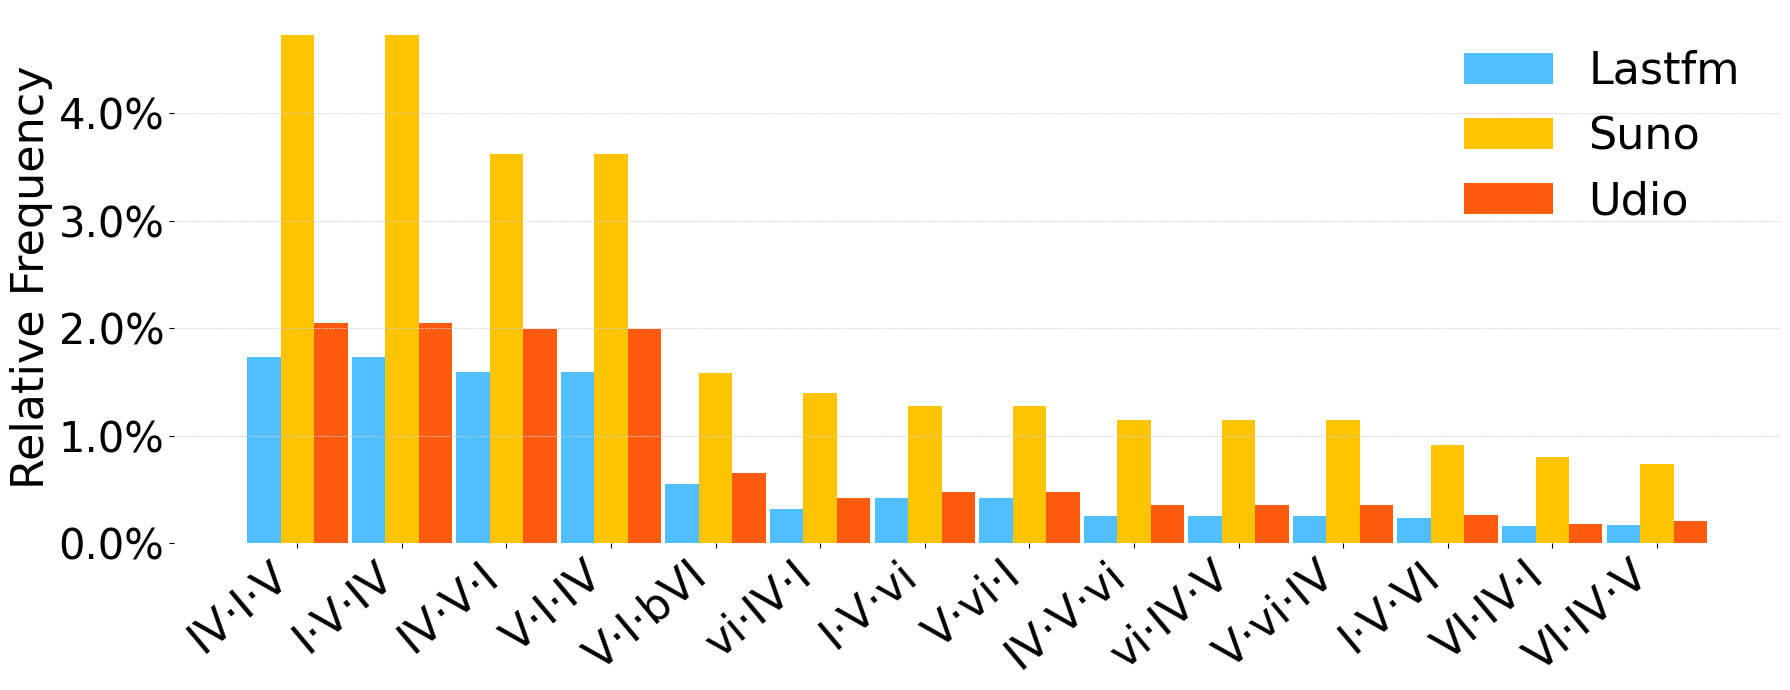

IV-I-V: Suno/Lastfm ratio: 2.73, Suno/Udio ratio: 2.31
I-V-IV: Suno/Lastfm ratio: 2.73, Suno/Udio ratio: 2.31
IV-V-I: Suno/Lastfm ratio: 2.27, Suno/Udio ratio: 1.82
V-I-IV: Suno/Lastfm ratio: 2.27, Suno/Udio ratio: 1.82
V-I-bVI: Suno/Lastfm ratio: 2.87, Suno/Udio ratio: 2.42
vi-IV-I: Suno/Lastfm ratio: 4.38, Suno/Udio ratio: 3.31
I-V-vi: Suno/Lastfm ratio: 3.01, Suno/Udio ratio: 2.67
V-vi-I: Suno/Lastfm ratio: 3.01, Suno/Udio ratio: 2.67
IV-V-vi: Suno/Lastfm ratio: 4.50, Suno/Udio ratio: 3.20
vi-IV-V: Suno/Lastfm ratio: 4.50, Suno/Udio ratio: 3.20
V-vi-IV: Suno/Lastfm ratio: 4.50, Suno/Udio ratio: 3.20
I-V-VI: Suno/Lastfm ratio: 3.85, Suno/Udio ratio: 3.41
VI-IV-I: Suno/Lastfm ratio: 5.07, Suno/Udio ratio: 4.34
VI-IV-V: Suno/Lastfm ratio: 4.24, Suno/Udio ratio: 3.48


In [110]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

collections = ['lastfm', 'suno', 'udio']
trigram_results  = sorted(trigram_results, key=lambda d: d["suno_prop"], reverse=True)

# Prepare the data
trigram_names = [row['Trigram'].replace('-', '·') for row in trigram_results]
proportions = {col: [row[f"{col}_prop"] for row in trigram_results] for col in collections}

# Bar width and positions
bar_width = 0.32
x = np.arange(len(trigram_names))

fig, ax = plt.subplots(figsize=(18, 7))
colors = ['#51BFFF', '#FFC400', '#FF5B0E']  # lastfm, suno, udio

for i, col in enumerate(collections):
    ax.bar(x + i * bar_width, proportions[col], width=bar_width, label=col.capitalize(), color=colors[i])

text_size = 32
ax.set_xticks(x + bar_width)
ax.set_xticklabels(trigram_names, rotation=40, ha='right', fontsize=text_size)
ax.set_ylabel('Relative Frequency', fontsize=text_size)
# ax.set_title('Prevalence of Canonical Pop Trigrams Across Collections', fontsize=text_size, pad=20)
ax.legend(title="", fontsize=text_size, title_fontsize=14, frameon=False)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
ax.tick_params(axis='y', labelsize=text_size-2)

ax.grid(axis='y',                      # only horizontal lines
        linestyle='--',                # dashed
        linewidth=0.5,
        color="#cdcdcd",
        alpha=1.0) 

# Optionally annotate significant results
for i, row in enumerate(trigram_results):
    sig = (row['suno_vs_lastfm_p'] < 0.05) and (row['suno_vs_udio_p'] < 0.05)
    if sig:
        y = proportions['suno'][i]
        ax.text(x[i] + bar_width, y, '', color='gray', ha='center', fontsize=20, fontweight='bold')


for spine in ax.spines.values():
    spine.set_visible(False)
    
plt.tight_layout()
plt.show()

for row in trigram_results:
    suno_prop = row["suno_prop"]
    lastfm_prop = row["lastfm_prop"]
    udio_prop = row["udio_prop"]
    suno_vs_lastfm_ratio = suno_prop / lastfm_prop if lastfm_prop else float('inf')
    suno_vs_udio_ratio = suno_prop / udio_prop if udio_prop else float('inf')
    print(f"{row['Trigram']}: Suno/Lastfm ratio: {suno_vs_lastfm_ratio:.2f}, Suno/Udio ratio: {suno_vs_udio_ratio:.2f}")



In [111]:
for row in trigram_results:
    suno_prop = row["suno_prop"]
    lastfm_prop = row["lastfm_prop"]
    udio_prop = row["udio_prop"]
    suno_vs_lastfm_ratio = suno_prop / lastfm_prop if lastfm_prop else float('inf')
    suno_vs_udio_ratio = suno_prop / udio_prop if udio_prop else float('inf')
    p_lastfm = row.get('suno_vs_lastfm_p', float('nan'))
    p_udio = row.get('suno_vs_udio_p', float('nan'))
    print(
        f"{row['Trigram']}: "
        f"Suno/Lastfm ratio: {suno_vs_lastfm_ratio:.2f} (p={p_lastfm:.2g}), "
        f"Suno/Udio ratio: {suno_vs_udio_ratio:.2f} (p={p_udio:.2g})"
    )


IV-I-V: Suno/Lastfm ratio: 2.73 (p=0), Suno/Udio ratio: 2.31 (p=0)
I-V-IV: Suno/Lastfm ratio: 2.73 (p=0), Suno/Udio ratio: 2.31 (p=0)
IV-V-I: Suno/Lastfm ratio: 2.27 (p=0), Suno/Udio ratio: 1.82 (p=0)
V-I-IV: Suno/Lastfm ratio: 2.27 (p=0), Suno/Udio ratio: 1.82 (p=0)
V-I-bVI: Suno/Lastfm ratio: 2.87 (p=0), Suno/Udio ratio: 2.42 (p=0)
vi-IV-I: Suno/Lastfm ratio: 4.38 (p=0), Suno/Udio ratio: 3.31 (p=0)
I-V-vi: Suno/Lastfm ratio: 3.01 (p=0), Suno/Udio ratio: 2.67 (p=0)
V-vi-I: Suno/Lastfm ratio: 3.01 (p=0), Suno/Udio ratio: 2.67 (p=0)
IV-V-vi: Suno/Lastfm ratio: 4.50 (p=0), Suno/Udio ratio: 3.20 (p=0)
vi-IV-V: Suno/Lastfm ratio: 4.50 (p=0), Suno/Udio ratio: 3.20 (p=0)
V-vi-IV: Suno/Lastfm ratio: 4.50 (p=0), Suno/Udio ratio: 3.20 (p=0)
I-V-VI: Suno/Lastfm ratio: 3.85 (p=0), Suno/Udio ratio: 3.41 (p=0)
VI-IV-I: Suno/Lastfm ratio: 5.07 (p=0), Suno/Udio ratio: 4.34 (p=0)
VI-IV-V: Suno/Lastfm ratio: 4.24 (p=0), Suno/Udio ratio: 3.48 (p=0)


In [112]:
from collections import Counter
import json, pathlib

def trigram_counts(path: str):
    """
    Read one JSON trigram file and return
    (Counter{trigram -> count}, total_count)
    """
    with open(path) as f:
        data = json.load(f)

    c = Counter()
    for row in data:                       # each row: {'ngram': [...], 'count': N}
        trigram = tuple(row['ngram'])
        n       = row.get('count', 1)
        c[trigram] += n
    return c, sum(c.values())

# ---- adjust the paths if yours live elsewhere ----
suno_counts,  total_suno  = trigram_counts("../ngram_datasets/trigrams/3gram_dataset_suno.json")
last_counts,  total_last  = trigram_counts("../ngram_datasets/trigrams/3gram_dataset_lastfm.json")

print(f"Suno trigrams loaded:  {total_suno:,}")
print(f"Last‑fm trigrams loaded: {total_last:,}")
print(f"Example Suno count for ('I','V','vi'):", suno_counts.get(('I','V','vi'), 0))


Suno trigrams loaded:  1,616,453
Last‑fm trigrams loaded: 2,480,124
Example Suno count for ('I','V','vi'): 13964


In [113]:
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import numpy as np


rows = []
for tri in trigram_targets:
    c_suno  = suno_counts.get(tri, 0)
    c_last  = last_counts.get(tri, 0)
    N_suno  = total_suno
    N_last  = total_last

    # proportions
    p_suno  = c_suno / N_suno if N_suno else 0
    p_last  = c_last / N_last if N_last else 0

    # effect size
    rr      = np.inf if p_last==0 else p_suno / p_last
    lor     = np.log2( ((c_suno+0.5)/(N_suno-c_suno+0.5)) /
                       ((c_last+0.5)/(N_last-c_last+0.5)) )

    # Fisher
    _, pval = fisher_exact([[c_suno, N_suno-c_suno],
                            [c_last, N_last-c_last]])

    rows.append((tri, c_suno, c_last, p_suno, p_last, rr, lor, pval))

df = pd.DataFrame(rows, columns=[
    'trigram','c_suno','c_last','p_suno','p_last','risk_ratio',
    'log2_odds_ratio','p'
])

# FDR correction
df['padj'] = multipletests(df['p'], method='fdr_bh')[1]

# Sort by enrichment
df = df.sort_values('risk_ratio', ascending=False)

display(df[['trigram','risk_ratio','log2_odds_ratio','padj']])


,trigram,risk_ratio,log2_odds_ratio,padj
5,"(VI, IV, I)",7.045115,2.823437,0.000000e+00
6,"(V, vi, IV)",6.668016,2.742326,0.000000e+00
4,"(vi, IV, I)",6.432345,2.695914,0.000000e+00
0,"(I, V, VI)",5.928222,2.575632,0.000000e+00
2,"(I, V, vi)",5.001159,2.332169,0.000000e+00
3,"(vi, IV, V)",4.585915,2.200922,0.000000e+00
11,"(VI, IV, V)",4.577206,2.196698,0.000000e+00
7,"(V, I, bVI)",3.700828,1.893964,0.000000e+00
8,"(IV, I, V)",3.520947,1.842666,0.000000e+00
1,"(IV, V, vi)",3.184612,1.674573,0.000000e+00


In [114]:
import numpy as np, pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# -------------------------------------------------------------
# 1 · Re‑compute the Suno‑vs‑Last‑fm stats for every trigram
# -------------------------------------------------------------
vocab = set(suno_counts) | set(last_counts)
rows  = []
for tri in vocab:
    cs = suno_counts.get(tri, 0)
    cl = last_counts.get(tri, 0)

    lor = np.log2(((cs+0.5)/(total_suno-cs+0.5)) /
                  ((cl+0.5)/(total_last-cl+0.5)))
    rr  = np.inf if cl == 0 else (cs/total_suno) / (cl/total_last)
    _, pval = fisher_exact([[cs, total_suno-cs],
                            [cl, total_last-cl]])
    rows.append((tri, cs, cl, rr, lor, pval))

df_all = pd.DataFrame(rows, columns=[
    "trigram","c_suno","c_last","risk_ratio","log2_odds_ratio","p-value"])

df_all["p-value"] = multipletests(df_all["p-value"], method="fdr_bh")[1]

# -------------------------------------------------------------
# 2 · Optionally keep only “reliable” trigrams
#     (comment these 4 lines out if you truly want *every* trigram)
# -------------------------------------------------------------
MIN_SUNO, MIN_LAST, RR_MIN, SIG = 30, 10, 2, 0.05
mask = (
    (df_all["c_suno"] >= MIN_SUNO) &
    (df_all["c_last"] >= MIN_LAST) &
    (df_all["risk_ratio"] >= RR_MIN) &
    (df_all["p-value"]     <  SIG)
)
df_hits = df_all[mask].copy()

# -------------------------------------------------------------
# 3 · Add real‑world percentages
# -------------------------------------------------------------
df_hits["% suno"] = df_hits["c_suno"] / total_suno * 100
df_hits["% last"] = df_hits["c_last"] / total_last * 100

# -------------------------------------------------------------
# 3a · Flag canonical pop progressions with an asterisk
# -------------------------------------------------------------

df_hits['trigram'] = df_hits['trigram'].apply(
    lambda tri: f"*{tri}" if tri in trigram_targets else tri
)

# -------------------------------------------------------------
# 4 · Tidy column order & display
# -------------------------------------------------------------
cols = ["trigram","c_suno","c_last","% suno","% last",
        "risk_ratio","log2_odds_ratio","p-value"]
df_hits = df_hits[cols].sort_values("risk_ratio", ascending=False)

display(df_hits.head(20))

,trigram,c_suno,c_last,% suno,% last,risk_ratio,log2_odds_ratio,p-value
80700,"(iii, vi, ii)",263,22,0.016270,0.000887,18.341860,4.167609,3.278908e-76
88622,"(iii, VI, ii)",143,27,0.008847,0.001089,8.126108,3.001240,1.561236e-30
30940,"(vi, ii, V)",659,143,0.040768,0.005766,7.070656,2.818408,5.758554e-133
73902,"*('VI', 'IV', 'I')",9234,2011,0.571251,0.081085,7.045115,2.823437,0.000000e+00
73796,"(IV, iii, vi)",602,132,0.037242,0.005322,6.997338,2.803010,1.351599e-120
53463,"*('V', 'vi', 'IV')",7110,1636,0.439852,0.065964,6.668016,2.742326,0.000000e+00
19590,"*('vi', 'IV', 'I')",14166,3379,0.876363,0.136243,6.432345,2.695914,0.000000e+00
8327,"(iii, vi, II)",268,67,0.016580,0.002701,6.137200,2.609743,5.945473e-49
54079,"*('I', 'V', 'VI')",11035,2856,0.682668,0.115156,5.928222,2.575632,0.000000e+00
3617,"(V, VI, IV)",4249,1150,0.262859,0.046369,5.668905,2.505741,0.000000e+00


In [123]:
import json, numpy as np, pandas as pd
from collections import Counter
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# -------------------------------------------------------------
# 0 · Load trigram-count dictionaries for all three corpora
# -------------------------------------------------------------
counts, totals = {}, {}
for corpus in ["suno", "udio", "lastfm"]:
    path = f"/workspace/ngram_datasets/trigrams/3gram_dataset_{corpus}.json"
    c = Counter()
    with open(path) as f:
        for entry in json.load(f):
            trigram = tuple(entry["ngram"])
            c[trigram] += entry["count"]      # accumulate counts
    counts[corpus] = c
    totals[corpus] = sum(c.values())

suno_counts,  total_suno  = counts["suno"],   totals["suno"]
udio_counts,  total_udio  = counts["udio"],   totals["udio"]
last_counts,  total_last  = counts["lastfm"], totals["lastfm"]

# -------------------------------------------------------------
# 1 · Suno-vs-Last stats + capture Udio counts
# -------------------------------------------------------------
rows = []
for tri in set(suno_counts) | set(last_counts) | set(udio_counts):
    cs, cl, cu = suno_counts.get(tri, 0), last_counts.get(tri, 0), udio_counts.get(tri, 0)
    # Suno–vs–Last risk ratio (keep for sorting)
    rr = np.inf if cl == 0 else (cs / total_suno) / (cl / total_last)
    _, pval = fisher_exact([[cs, total_suno - cs],
                            [cl, total_last - cl]])
    rows.append((tri, cs, cu, cl, rr, pval))

df_all = pd.DataFrame(rows, columns=[
    "trigram", "c_suno", "c_udio", "c_last",
    "risk_ratio", "p_raw"
])
df_all["p_adj"] = multipletests(df_all["p_raw"], method="fdr_bh")[1]

# -------------------------------------------------------------
# 2 · Optional reliability filter
# -------------------------------------------------------------
MIN_SUNO, MIN_LAST, MIN_UDIO, RR_MIN, SIG = 30, 10, 10, 2, 0.05
mask = (
    (df_all["c_suno"]  >= MIN_SUNO) &
    (df_all["c_last"]  >= MIN_LAST) &
    (df_all["c_udio"]  >= MIN_UDIO) &
    (df_all["risk_ratio"] >= RR_MIN) &
    (df_all["p_adj"]      <  SIG)
)
df_hits = df_all[mask].copy()

# -------------------------------------------------------------
# 3 · Add percentages
# -------------------------------------------------------------
df_hits["% suno"] = df_hits["c_suno"] / total_suno  * 100
df_hits["% udio"] = df_hits["c_udio"] / total_udio  * 100
df_hits["% last"] = df_hits["c_last"] / total_last  * 100
sig_tris = set(df_hits["trigram"])

labels = [
    ('*' if tri in sig_tris else '') + ' · '.join(tri)
    for tri, _ in top_trigrams
]
# -------------------------------------------------------------
# 4 · Final tidy table (no log-odds or p-values)
# -------------------------------------------------------------
cols = ["trigram",
        "c_suno", 
        "c_udio", 
        "c_last", 
        "% suno",
        "% udio",
        "% last",
        "risk_ratio"]
df_final = df_hits[cols].sort_values("risk_ratio", ascending=False)

display(df_final.head(20))   # or to_csv / to_latex as you prefer


,trigram,c_suno,c_udio,c_last,% suno,% udio,% last,risk_ratio
90704,"(iii, vi, ii)",263,47,22,0.016270,0.003439,0.000887,18.341860
99585,"(iii, VI, ii)",143,51,27,0.008847,0.003732,0.001089,8.126108
34777,"(vi, ii, V)",659,141,143,0.040768,0.010318,0.005766,7.070656
83044,"(VI, IV, I)",9234,1298,2011,0.571251,0.094988,0.081085,7.045115
82930,"(IV, iii, vi)",602,139,132,0.037242,0.010172,0.005322,6.997338
60050,"(V, vi, IV)",7110,1320,1636,0.439852,0.096598,0.065964,6.668016
21961,"(vi, IV, I)",14166,2557,3379,0.876363,0.187122,0.136243,6.432345
9349,"(iii, vi, II)",268,55,67,0.016580,0.004025,0.002701,6.137200
60756,"(I, V, VI)",11035,1755,2856,0.682668,0.128431,0.115156,5.928222
4077,"(V, VI, IV)",4249,670,1150,0.262859,0.049031,0.046369,5.668905


In [116]:
import numpy as np, pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

import collections, json
from collections import Counter 

UDIO_PATH = "../ngram_datasets/trigrams/3gram_dataset_udio.json"

with open(UDIO_PATH) as f:
    data_udio = json.load(f)

udio_counts = Counter()
for row in data_udio:                 # each row: {'ngram': [...], 'count': n}
    tri = tuple(row['ngram'])
    udio_counts[tri] += row.get('count', 1)

total_udio = sum(udio_counts.values())
print(f"Udio trigrams loaded: {total_udio:,}")


# -------------------------------------------------------------
# 1 · Udio‑vs‑Last‑fm stats for every trigram
# -------------------------------------------------------------
vocab = set(udio_counts) | set(last_counts)
rows  = []
for tri in vocab:
    cu = udio_counts.get(tri, 0)
    cl = last_counts.get(tri, 0)

    lor = np.log2(((cu+0.5)/(total_udio-cu+0.5)) /
                  ((cl+0.5)/(total_last-cl+0.5)))
    rr  = np.inf if cl == 0 else (cu/total_udio) / (cl/total_last)
    _, pval = fisher_exact([[cu, total_udio-cu],
                            [cl, total_last-cl]])
    rows.append((tri, cu, cl, rr, lor, pval))

df_all = pd.DataFrame(rows, columns=[
    "trigram","c_udio","c_last","risk_ratio","log2_odds_ratio","p_raw"])

# FDR correction
df_all["padj"] = multipletests(df_all["p_raw"], method="fdr_bh")[1]

# -------------------------------------------------------------
# 2 · keep only reliable, enriched trigrams  (edit or comment out)
# -------------------------------------------------------------
MIN_UDIO, MIN_LAST, RR_MIN, SIG = 30, 10, 2, 0.05
mask = (
    (df_all["c_udio"]  >= MIN_UDIO) &
    (df_all["c_last"]  >= MIN_LAST) &
    (df_all["risk_ratio"] >= RR_MIN) &
    (df_all["padj"]      <  SIG)
)
df_hits = df_all[mask].copy()

# -------------------------------------------------------------
# 3 · add real‑world percentages
# -------------------------------------------------------------
df_hits["% udio"] = df_hits["c_udio"] / total_udio * 100
df_hits["% last"] = df_hits["c_last"] / total_last * 100

# -------------------------------------------------------------
# 3a · flag canonical pop progressions with an asterisk
# -------------------------------------------------------------
canonical_pop = {
    ('I','V','vi'), ('vi','IV','I'), ('IV','I','V'), ('IV','I','v'),
    ('IV','V','I'), ('V','I','IV'), ('VI','IV','I'), ('V','vi','IV'),
    ('V','I','bVI'), ('IV','v','I'), ('I','v','IV'), ('ii','V','I')
}
df_hits["trigram"] = df_hits["trigram"].apply(
    lambda tri: f"*{tri}" if tri in canonical_pop else tri
)

# -------------------------------------------------------------
# 4 · tidy & display
# -------------------------------------------------------------
cols = ["trigram","c_udio","c_last","% udio","% last",
        "risk_ratio","log2_odds_ratio","padj"]
df_hits = df_hits[cols].sort_values("risk_ratio", ascending=False)

display(df_hits.head(20))        # change head() or drop to see more


Udio trigrams loaded: 1,366,490


,trigram,c_udio,c_last,% udio,% last,risk_ratio,log2_odds_ratio,padj
79269,"(III, IV, bbIV75#32)",58,18,0.004244,0.000726,5.848203,2.520899,4.892902e-10
2989,"(iv, BVII, bII)",56,21,0.004098,0.000847,4.839892,2.253898,3.885048e-08
11937,"(#I, iv, III)",32,12,0.002342,0.000484,4.839892,2.238476,2.048332e-04
852,"(bvii, i, iv)",57,23,0.004171,0.000927,4.497943,2.150885,5.838402e-08
97024,"(III, i, #I)",37,15,0.002708,0.000605,4.476900,2.134590,7.889832e-05
86149,"(v, II, iv)",63,29,0.004610,0.001169,3.942843,1.966028,1.188889e-07
85299,"(iii, vi, ii)",47,22,0.003439,0.000887,3.877413,1.937976,1.722076e-05
48043,"(bvii, I, iv)",136,66,0.009953,0.002661,3.739917,1.897517,8.893801e-17
55067,"(bV, bVII, iv)",37,18,0.002708,0.000726,3.730750,1.879331,7.566990e-04
88076,"(v, bVI, bbVI)",39,19,0.002854,0.000766,3.725443,1.878346,3.732859e-04


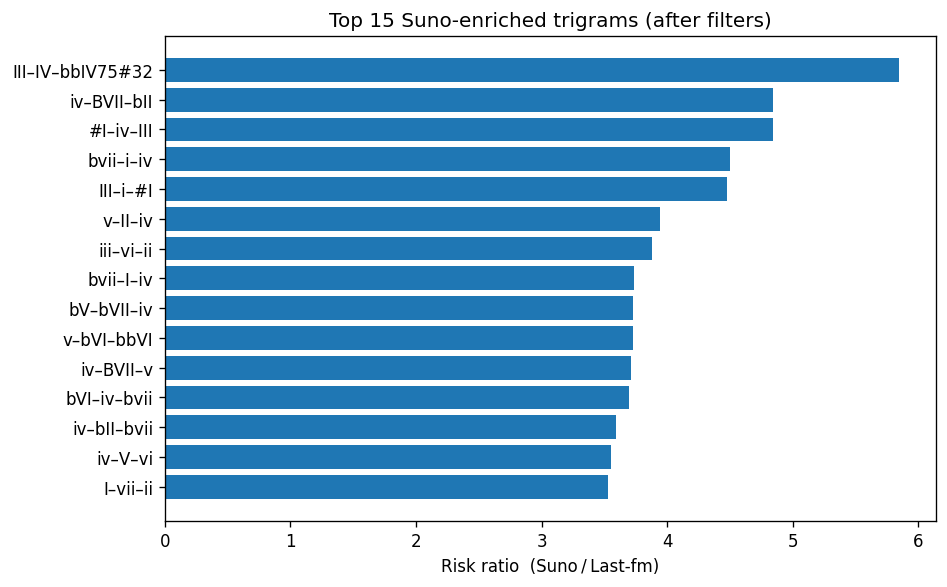

In [117]:
import matplotlib.pyplot as plt

TOP_N = 15
top15 = df_hits.head(TOP_N)

plt.figure(figsize=(8, 5), dpi=120)
plt.barh(
    ['–'.join(t) for t in top15['trigram']],   # y‑axis labels
    top15['risk_ratio']
)
plt.gca().invert_yaxis()
plt.xlabel("Risk ratio  (Suno / Last‑fm)")
plt.title(f"Top {TOP_N} Suno‑enriched trigrams (after filters)")
plt.tight_layout()
plt.show()


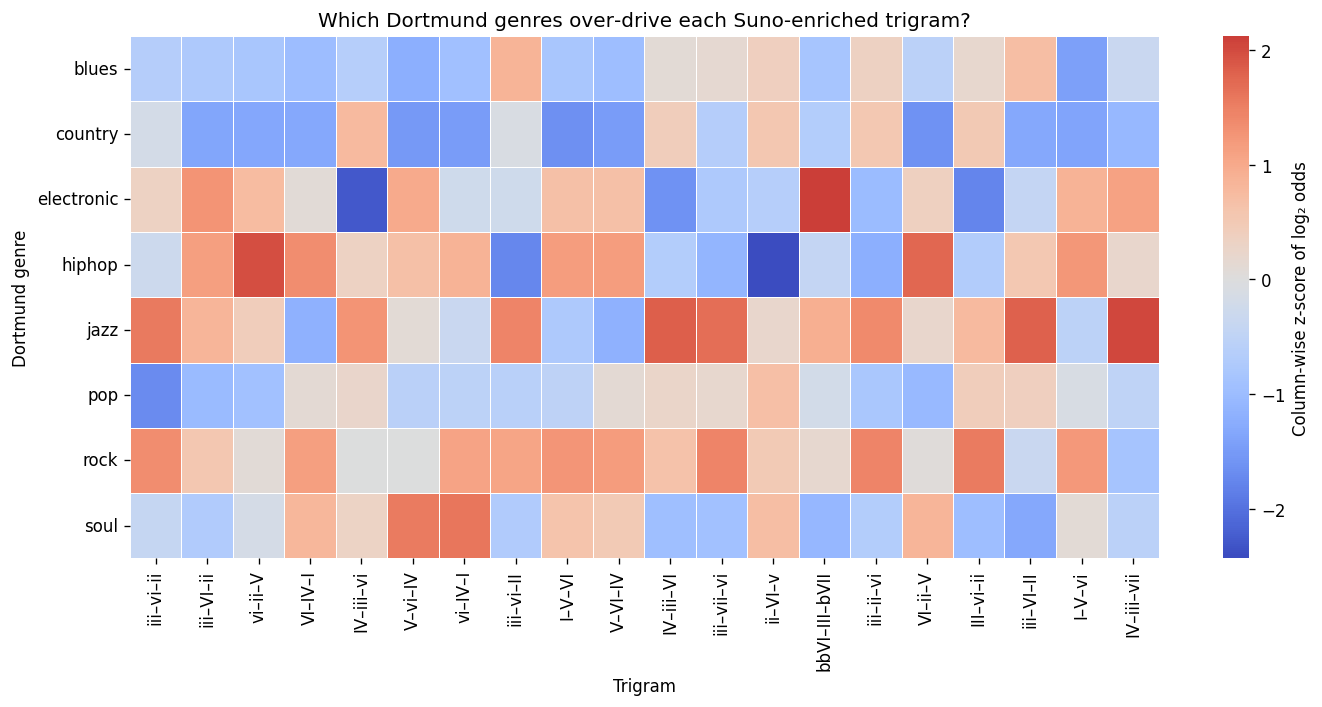

In [118]:
# ------------------------------------------------------------
# 0 · Imports
# ------------------------------------------------------------
import json, collections, numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1 · File paths
# ------------------------------------------------------------
FILES = {
    'Suno'  : "../ngram_datasets/trigrams/3gram_dataset_suno.json",
    'Udio'  : "../ngram_datasets/trigrams/3gram_dataset_udio.json",
    'Lastfm': "../ngram_datasets/trigrams/3gram_dataset_lastfm.json",
}

# ------------------------------------------------------------
# 2 · Pass 1: corpus‑level counts (for df_hits)
# ------------------------------------------------------------
suno_counts = collections.Counter()
last_counts = collections.Counter()
total_suno  = 0
total_last  = 0

for collection, path in FILES.items():
    with open(path) as f:
        data = json.load(f)

    for row in data:
        tri   = tuple(row["ngram"])
        n     = row.get("count", 1)          # integer count per corpus
        if collection == "Suno":
            suno_counts[tri] += n
            total_suno       += n
        elif collection == "Lastfm":
            last_counts[tri] += n
            total_last       += n
        # Udio is ignored for Suno‑vs‑Lastfm comparison

# ------------------------------------------------------------
# 3 · Compute enrichment table (df_hits)  ── identical logic
# ------------------------------------------------------------
vocab = set(suno_counts) | set(last_counts)
rows  = []
for tri in vocab:
    cs = suno_counts.get(tri, 0)
    cl = last_counts.get(tri, 0)

    lor = np.log2(((cs+0.5)/(total_suno-cs+0.5)) /
                  ((cl+0.5)/(total_last-cl+0.5)))
    rr  = np.inf if cl == 0 else (cs/total_suno) / (cl/total_last)
    _, pval = fisher_exact([[cs, total_suno-cs],
                            [cl, total_last-cl]])

    rows.append((tri, cs, cl, rr, lor, pval))

df_all = pd.DataFrame(rows, columns=[
    "trigram","c_suno","c_last",
    "risk_ratio","log2_odds_ratio","p"
])

df_all["padj"] = multipletests(df_all["p"], method="fdr_bh")[1]

# relevance thresholds
MIN_SUNO, MIN_LAST, RR_MIN, SIG = 30, 10, 2, 0.05
mask = (
    (df_all["c_suno"] >= MIN_SUNO) &
    (df_all["c_last"] >= MIN_LAST) &
    (df_all["risk_ratio"] >= RR_MIN) &
    (df_all["padj"] < SIG)
)
df_hits = df_all[mask].copy()

# drop the 12 canonical targets (optional)
# targets = [
#     ('I','V','vi'), ('vi','IV','I'), ('IV','I','V'), ('IV','I','v'),
#     ('IV','V','I'), ('V','I','IV'), ('VI','IV','I'), ('V','vi','IV'),
#     ('V','I','bVI'), ('IV','v','I'), ('I','v','IV'), ('ii','V','I')
# ]
# df_hits = df_hits[~df_hits["trigram"].isin(targets)]
df_hits = df_hits.sort_values("risk_ratio", ascending=False)

# add real‑world percentages
df_hits["pct_suno"] = df_hits["c_suno"] / total_suno * 100
df_hits["pct_last"] = df_hits["c_last"] / total_last * 100

# ------------------------------------------------------------
# 4 · Pass 2: genre‑level counters using DORTMUND genres only
# ------------------------------------------------------------
genre_coll_counters = collections.defaultdict(collections.Counter)
total_by_row        = collections.Counter()

for collection, path in FILES.items():
    with open(path) as f:
        data = json.load(f)

    for row in data:
        tri    = tuple(row["ngram"])
        # ---------- ONLY Dortmund genres ----------
        for genre, weight in row.get("dortmund_genres", []):
            genre = genre.lower()
            genre_coll_counters[(genre, collection)][tri] += weight
            total_by_row[(genre, collection)]             += weight
        # ------------------------------------------

# ------------------------------------------------------------
# 5 · Heat‑map of genre‑specific log‑odds ratios
# ------------------------------------------------------------
top_tris = df_hits["trigram"].head(20)      # choose how many columns to show
genres   = sorted({g for (g, coll) in genre_coll_counters
                   if coll in ("Suno", "Lastfm")})

mat = []
for g in genres:
    cs_ctr = genre_coll_counters.get((g,"Suno"),   {})
    cl_ctr = genre_coll_counters.get((g,"Lastfm"), {})
    cs_tot = total_by_row.get((g,"Suno"),   0)
    cl_tot = total_by_row.get((g,"Lastfm"), 0)
    vals = []
    for tri in top_tris:
        cs = cs_ctr.get(tri,0)
        cl = cl_ctr.get(tri,0)
        lor = np.log2(((cs+0.5)/(cs_tot-cs+0.5)) /
                      ((cl+0.5)/(cl_tot-cl+0.5)))
        vals.append(lor)
    mat.append(vals)

H = pd.DataFrame(mat, index=genres,
                 columns=["–".join(t) for t in top_tris])

# column‑wise z‑score
H_z = (H - H.mean()) / H.std(ddof=0)

plt.figure(figsize=(12,6), dpi=120)
sns.heatmap(
    H_z, cmap="coolwarm", center=0, linewidths=.5,
    cbar_kws=dict(label="Column‑wise z‑score of log₂ odds")
)
plt.title("Which Dortmund genres over‑drive each Suno‑enriched trigram?")
plt.ylabel("Dortmund genre"); plt.xlabel("Trigram")
plt.tight_layout(); plt.show()



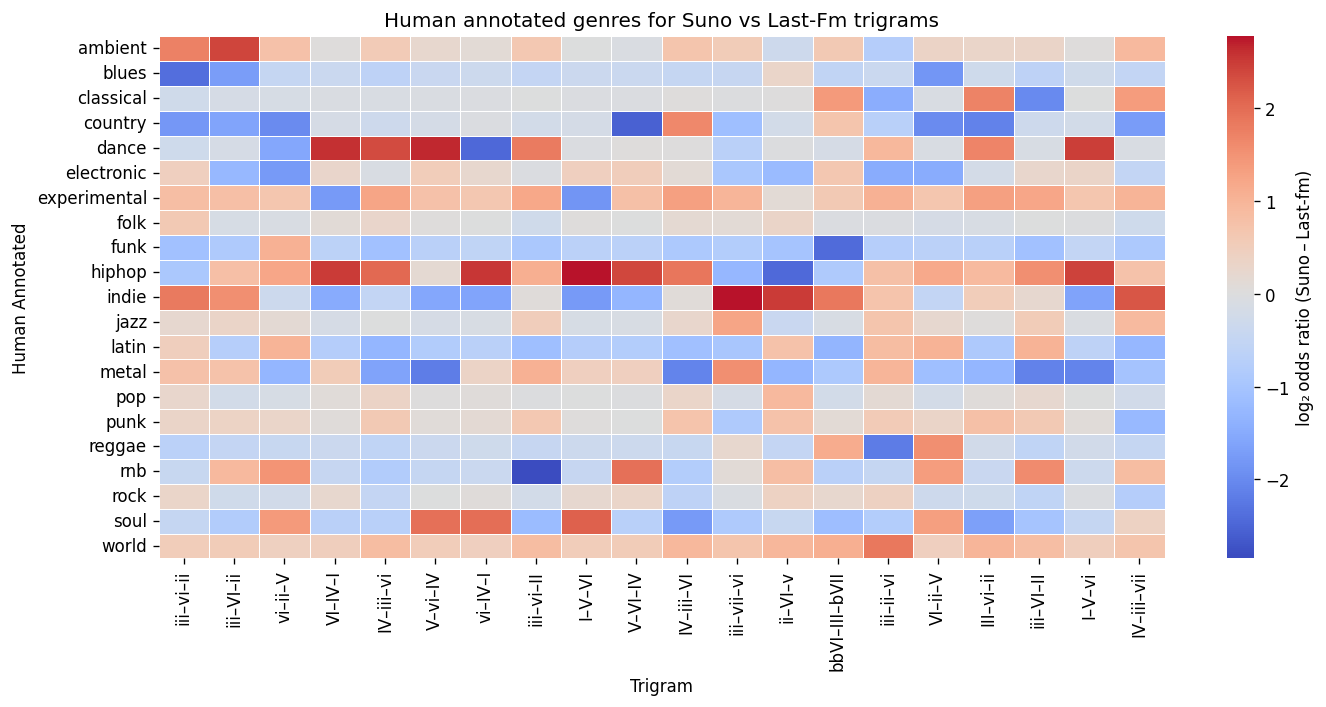

In [119]:
# -----------------------------------------------------------------
# 1 · rebuild genre_coll_counters_HUMAN (normalised)
# -----------------------------------------------------------------
import json, collections, numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

FILES = {
    'Suno'  : "../ngram_datasets/trigrams/3gram_dataset_suno.json",
    'Udio'  : "../ngram_datasets/trigrams/3gram_dataset_udio.json",
    'Lastfm': "../ngram_datasets/trigrams/3gram_dataset_lastfm.json",
}

genre_coll_human = collections.defaultdict(collections.Counter)
totals_human     = collections.Counter()

for collection, path in FILES.items():
    with open(path) as f:
        data = json.load(f)
    for row in data:
        tri = tuple(row["ngram"])
        for style, n in row.get("human_styles", []):
            g = normalize_style(style).lower()
            genre_coll_human[(g, collection)][tri] += n
            totals_human[(g, collection)]          += n

# -----------------------------------------------------------------
# 2 · heat‑map using the SAME top_tris as before
# -----------------------------------------------------------------
top_tris = df_hits["trigram"].head(20)   # uses the df_hits you already built
genres_h = sorted({g for (g,c) in genre_coll_human if c in ("Suno","Lastfm")})

matrix = []
for g in genres_h:
    cs_ctr = genre_coll_human.get((g,'Suno'),   {})
    cl_ctr = genre_coll_human.get((g,'Lastfm'), {})
    cs_tot = totals_human.get((g,'Suno'),   0)
    cl_tot = totals_human.get((g,'Lastfm'), 0)
    vals = []
    for tri in top_tris:
        cs = cs_ctr.get(tri,0)
        cl = cl_ctr.get(tri,0)
        lor = np.log2(((cs+0.5)/(cs_tot-cs+0.5)) /
                      ((cl+0.5)/(cl_tot-cl+0.5)))
        vals.append(lor)
    matrix.append(vals)

H_human = pd.DataFrame(matrix, index=genres_h,
                       columns=["–".join(t) for t in top_tris])

# -----------------------------------------------------------------
# 3 · plot
# -----------------------------------------------------------------
plt.figure(figsize=(12,6), dpi=120)
H_z = (H_human - H_human.mean()) / H_human.std(ddof=0)
sns.heatmap(
    H_z, cmap="coolwarm", center=0, linewidths=.5,
    cbar_kws=dict(label="log₂ odds ratio (Suno – Last‑fm)")
)
plt.title("Human annotated genres for Suno vs Last-Fm trigrams")
plt.ylabel("Human Annotated"); plt.xlabel("Trigram")
plt.tight_layout(); plt.show()

In [120]:
def top_genres_for(tri, top=5):
    genre_counts = {g: ctr.get(tri,0)
                    for (g, coll), ctr in genre_coll_counters.items()
                    if coll == 'Suno'}
    return sorted(genre_counts.items(), key=lambda x:x[1], reverse=True)[:top]

for tri in df_hits['trigram'].head(10):
    print(f"\n{tri}:")
    for g, n in top_genres_for(tri):
        print(f"  {g:<12} {n}")



('iii', 'vi', 'ii'):
  jazz         58.696293911
  pop          53.016358010099985
  country      49.20190127917006
  rock         36.90195519890202
  electronic   21.340477319059993

('iii', 'VI', 'ii'):
  jazz         43.130812068000026
  pop          21.164107092800013
  country      18.99618668149999
  electronic   17.830173859400013
  rock         15.979650414329999

('vi', 'ii', 'V'):
  jazz         180.2330981870001
  pop          116.05314863664027
  country      102.99873066660001
  rock         76.69334218783992
  electronic   60.32257317578994

('VI', 'IV', 'I'):
  rock         3020.712629710956
  pop          1666.6356005944963
  electronic   1219.998575612795
  country      1150.4133457318342
  jazz         1038.4777951546046

('IV', 'iii', 'vi'):
  pop          124.52450306900042
  jazz         124.52347504600012
  country      107.27987623949998
  rock         103.10326520722016
  electronic   52.261076992300104

('V', 'vi', 'IV'):
  rock         1712.0075399578452
  po